# 1.2 — Generación de etiquetas no supervisadas para nonMalignant

**Objetivo**: Generar etiquetas de cluster para las muestras nonMalignant de forma
**totalmente independiente** entre train y test (sin filtración de información).

Pipeline por conjunto: `log1p → StandardScaler → PCA(90%) → KMeans(k=2)`

Las etiquetas se alinean entre conjuntos mediante la proporción de *Asymptomatic controls*
en cada cluster.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

from genomics_dl.models.heterogeneity import (
    generate_nonmalignant_clusters,
    align_cluster_labels,
    compute_umap_from_pca,
    plot_umap,
)
from genomics_dl.models.train_multiclass import build_y_multiclass_with_clusters

In [3]:
DATA_PROCESSED = Path("../data/processed")

TRAIN_PATH = DATA_PROCESSED / "gse183635_tep_tpm_train.parquet"
TEST_PATH  = DATA_PROCESSED / "gse183635_tep_tpm_test.parquet"

OUT_TRAIN = DATA_PROCESSED / "gse183635_tep_tpm_train_clustered.parquet"
OUT_TEST  = DATA_PROCESSED / "gse183635_tep_tpm_test_clustered.parquet"

RANDOM_STATE = 42
PCA_VARIANCE = 0.90
N_CLUSTERS = 2

metadata_cols = [
    "Sample ID", "Patient_group", "Stage", "Sex", "Age",
    "Sample-supplying institution", "Training series",
    "Evaluation series", "Validation series", "lib.size",
    "classificationScoreCancer", "Class_group",
]

## Carga de datos

In [4]:
df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)

if "Sample ID" in df_train.columns:
    df_train = df_train.set_index("Sample ID", drop=False)
if "Sample ID" in df_test.columns:
    df_test = df_test.set_index("Sample ID", drop=False)

gene_cols = [c for c in df_train.columns if c not in metadata_cols]

print(f"Train: {len(df_train)} muestras, Test: {len(df_test)} muestras")
print(f"Genes: {len(gene_cols)}")

Train: 1880 muestras, Test: 471 muestras
Genes: 5440


## Filtrar nonMalignant

In [5]:
mask_nm_train = df_train["Class_group"] == "nonMalignant"
mask_nm_test  = df_test["Class_group"] == "nonMalignant"

X_nm_train = df_train.loc[mask_nm_train, gene_cols]
X_nm_test  = df_test.loc[mask_nm_test, gene_cols]

meta_nm_train = df_train.loc[mask_nm_train, metadata_cols].copy()
meta_nm_test  = df_test.loc[mask_nm_test, metadata_cols].copy()

print(f"nonMalignant train: {X_nm_train.shape}")
print(f"nonMalignant test:  {X_nm_test.shape}")

nonMalignant train: (578, 5440)
nonMalignant test:  (145, 5440)


## Clustering independiente en train y test

In [6]:
labels_train, scaler_train, pca_train = generate_nonmalignant_clusters(
    X_nm_train,
    pca_variance=PCA_VARIANCE,
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
)
print(f"Train — PCA componentes: {pca_train.n_components_}, clusters: {np.unique(labels_train)}")
print(f"Train — distribución: {dict(zip(*np.unique(labels_train, return_counts=True)))}")

Train — PCA componentes: 268, clusters: [0 1]
Train — distribución: {np.int32(0): np.int64(385), np.int32(1): np.int64(193)}


In [7]:
labels_test, scaler_test, pca_test = generate_nonmalignant_clusters(
    X_nm_test,
    pca_variance=PCA_VARIANCE,
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
)
print(f"Test — PCA componentes: {pca_test.n_components_}, clusters: {np.unique(labels_test)}")
print(f"Test — distribución: {dict(zip(*np.unique(labels_test, return_counts=True)))}")

Test — PCA componentes: 73, clusters: [0 1]
Test — distribución: {np.int32(0): np.int64(82), np.int32(1): np.int64(63)}


## Alineación de etiquetas

In [8]:
labels_train_al, labels_test_al = align_cluster_labels(
    labels_train, labels_test,
    meta_nm_train, meta_nm_test,
    reference_group="Asymptomatic controls",
    patient_group_col="Patient_group",
)

print("Train alineado:", dict(zip(*np.unique(labels_train_al, return_counts=True))))
print("Test alineado: ", dict(zip(*np.unique(labels_test_al, return_counts=True))))

Train alineado: {np.int32(0): np.int64(385), np.int32(1): np.int64(193)}
Test alineado:  {np.int32(0): np.int64(82), np.int32(1): np.int64(63)}


## Validación: crosstab Patient_group × cluster

In [9]:
meta_nm_train["nm_cluster"] = labels_train_al
meta_nm_test["nm_cluster"]  = labels_test_al

print("=== TRAIN ===")
ct_train = pd.crosstab(meta_nm_train["nm_cluster"], meta_nm_train["Patient_group"])
display(ct_train)

chi2_tr, p_tr, _, _ = chi2_contingency(ct_train)
print(f"Chi2 Patient_group vs cluster (train): {chi2_tr:.2f}, p={p_tr:.2e}")

print("\n=== TEST ===")
ct_test = pd.crosstab(meta_nm_test["nm_cluster"], meta_nm_test["Patient_group"])
display(ct_test)

chi2_te, p_te, _, _ = chi2_contingency(ct_test)
print(f"Chi2 Patient_group vs cluster (test): {chi2_te:.2f}, p={p_te:.2e}")

=== TRAIN ===


Patient_group,Angina pectoris,Asymptomatic controls,Bowel disease,Former sarcoma,Hematuria,Medically-intractable epilepsy,Multiple sclerosis,Pancreatic diseases,Pulmonary Hypertension,nSTEMI
nm_cluster,,,,,,,,,,
0,6,221,3,3,4,22,54,35,34,3
1,16,89,2,14,1,14,14,9,25,9


Chi2 Patient_group vs cluster (train): 57.48, p=4.09e-09

=== TEST ===


Patient_group,Angina pectoris,Asymptomatic controls,Bowel disease,Former sarcoma,Medically-intractable epilepsy,Multiple sclerosis,Pancreatic diseases,Pulmonary Hypertension,nSTEMI
nm_cluster,,,,,,,,,
0,0,52,2,3,6,10,3,5,1
1,4,28,2,6,2,8,3,8,2


Chi2 Patient_group vs cluster (test): 13.18, p=1.06e-01


## Validación: crosstab Institución × cluster

In [10]:
print("=== TRAIN ===")
display(pd.crosstab(meta_nm_train["nm_cluster"], meta_nm_train["Sample-supplying institution"]))

print("\n=== TEST ===")
display(pd.crosstab(meta_nm_test["nm_cluster"], meta_nm_test["Sample-supplying institution"]))

=== TRAIN ===


Sample-supplying institution,Institute 1,Institute 10,Institute 11,Institute 12,Institute 13,Institute 3,Institute 4,Institute 5,Institute 7,Institute 8
nm_cluster,,,,,,,,,,
0,8,29,6,6,291,18,15,3,0,9
1,0,28,1,2,114,0,0,45,1,2



=== TEST ===


Sample-supplying institution,Institute 1,Institute 10,Institute 11,Institute 12,Institute 13,Institute 3,Institute 4,Institute 5,Institute 8
nm_cluster,,,,,,,,,
0,1,6,2,3,57,3,4,3,3
1,0,6,1,3,40,0,0,11,2


## UMAP — Visualización de clusters

/workspaces/TFM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


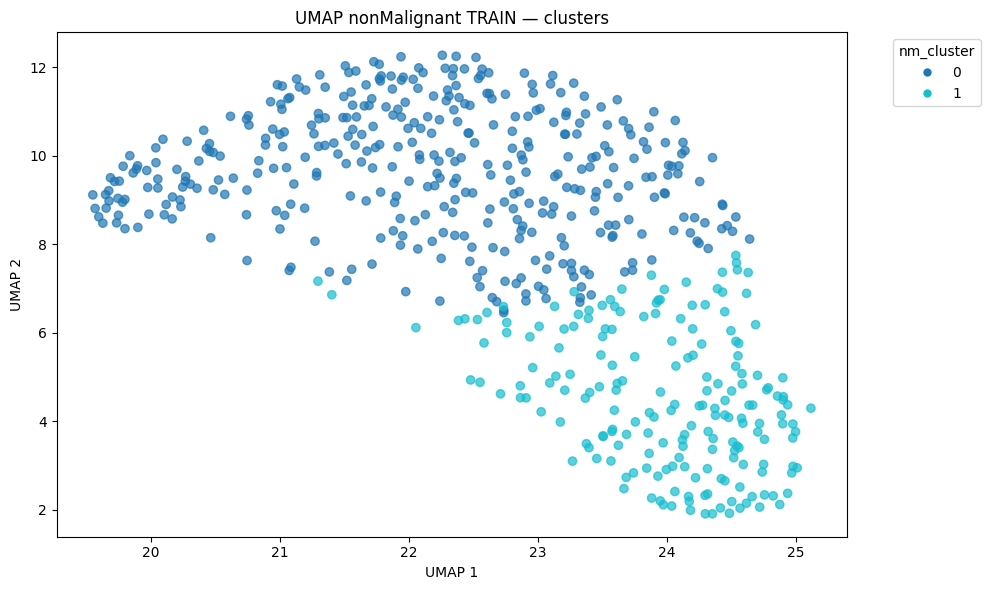

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Recalcular PCA para UMAP (train)
X_log_train = np.log1p(X_nm_train.values)
X_scaled_train = scaler_train.transform(X_log_train)
X_pca_train = pca_train.transform(X_scaled_train)

X_umap_train, _ = compute_umap_from_pca(X_pca_train, random_state=RANDOM_STATE)

plot_umap(
    X_umap=X_umap_train,
    color=pd.Series(labels_train_al, index=meta_nm_train.index, name="nm_cluster"),
    title="UMAP nonMalignant TRAIN — clusters",
    figsize=(10, 6),
)

/workspaces/TFM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


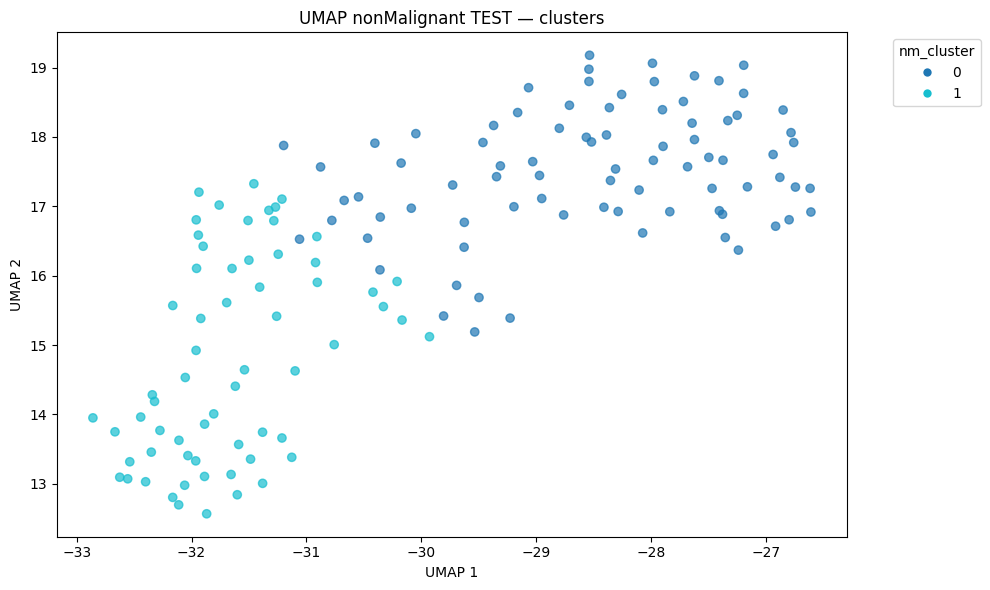

In [12]:
# UMAP para test
X_log_test = np.log1p(X_nm_test.values)
X_scaled_test = scaler_test.transform(X_log_test)
X_pca_test = pca_test.transform(X_scaled_test)

X_umap_test, _ = compute_umap_from_pca(X_pca_test, random_state=RANDOM_STATE)

plot_umap(
    X_umap=X_umap_test,
    color=pd.Series(labels_test_al, index=meta_nm_test.index, name="nm_cluster"),
    title="UMAP nonMalignant TEST — clusters",
    figsize=(10, 6),
)

## Guardar datos enriquecidos con clusters

In [13]:
# Añadir columna nm_cluster (NaN para Malignant)
df_train["nm_cluster"] = np.nan
df_train.loc[mask_nm_train, "nm_cluster"] = labels_train_al.astype(float)

df_test["nm_cluster"] = np.nan
df_test.loc[mask_nm_test, "nm_cluster"] = labels_test_al.astype(float)

print("Train nm_cluster:")
print(df_train["nm_cluster"].value_counts(dropna=False))
print("\nTest nm_cluster:")
print(df_test["nm_cluster"].value_counts(dropna=False))

Train nm_cluster:
nm_cluster
NaN    1302
0.0     385
1.0     193
Name: count, dtype: int64

Test nm_cluster:
nm_cluster
NaN    326
0.0     82
1.0     63
Name: count, dtype: int64


In [14]:
df_train.to_parquet(OUT_TRAIN, index=False)
df_test.to_parquet(OUT_TEST, index=False)

print(f"Guardado: {OUT_TRAIN}")
print(f"Guardado: {OUT_TEST}")

Guardado: ../data/processed/gse183635_tep_tpm_train_clustered.parquet
Guardado: ../data/processed/gse183635_tep_tpm_test_clustered.parquet


## Preview: distribución de 20 clases

In [15]:
y_train_20 = build_y_multiclass_with_clusters(
    df_train,
    class_group_col="Class_group",
    patient_group_col="Patient_group",
    cluster_col="nm_cluster",
)

print("Distribución de clases (train, 20 clases):")
print(pd.Series(y_train_20).value_counts())

y_test_20 = build_y_multiclass_with_clusters(
    df_test,
    class_group_col="Class_group",
    patient_group_col="Patient_group",
    cluster_col="nm_cluster",
)

print("\nDistribución de clases (test, 20 clases):")
print(pd.Series(y_test_20).value_counts())

Distribución de clases (train, 20 clases):
Non-small-cell lung cancer    417
nonMalignant_0                385
nonMalignant_1                193
Ovarian cancer                114
Glioma                        113
Pancreatic cancer              93
Breast cancer                  80
Head and neck cancer           79
Cholangiocarcinoma             71
Colorectal cancer              69
Melanoma                       54
Sarcoma                        44
Endometrial cancer             34
Prostate cancer                23
Multiple Myeloma               22
Urothelial cancer              22
Renal cell cancer              20
Hepatocellular carcinoma       19
Lymphoma                       16
Esophageal carcinoma           12
Name: count, dtype: int64

Distribución de clases (test, 20 clases):
Non-small-cell lung cancer    105
nonMalignant_0                 82
nonMalignant_1                 63
Pancreatic cancer              33
Ovarian cancer                 30
Head and neck cancer           22
Glio